## Import packages

In [1]:
import sys
sys.path.append('..')

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import prepare_data, create_sequences
from src import build_lstm_model
from src import train_model, evaluate_model

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'text.color': 'black',
    'legend.facecolor': 'white',
    'legend.edgecolor': 'black'
})


## Load engineered data and selected features

In [2]:
df = pd.read_csv('../data/raw/featured_data.csv', index_col=0, parse_dates=True)

with open('../data/raw/selected_features.json', 'r') as f:
    selected_features = json.load(f)

ticker = "AAPL"
print(f"Loaded data: {df.shape}")
print(f"Selected features ({len(selected_features)}): {selected_features}")
df[selected_features].head()

,Close,Volume_SMA_20,Volume,MACD_Signal
Date,,,,
2021-05-24,124.005119,92606460.0,63092900,-0.703716
2021-05-25,123.809967,92906145.0,72009500,-0.733561
2021-05-26,123.761185,90346935.0,56575900,-0.743369
2021-05-27,122.229424,87523165.0,94625600,-0.762847
2021-05-28,121.575729,85596745.0,71311100,-0.796056


## Prepare data (scale and split)

In [3]:
test_size = 0.2
train_data, test_data, scaler = prepare_data(
    df,
    feature_columns=selected_features,
    test_size=test_size
)

print(f"Training samples: {len(train_data)}")
print(f"Testing samples: {len(test_data)}")

Training samples: 965
Testing samples: 242


## Create sequences

In [4]:

seq_length = 60

X_train, y_train = create_sequences(train_data, seq_length=seq_length)
X_test, y_test = create_sequences(test_data, seq_length=seq_length)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (905, 60, 4)
y_train shape: (905,)
X_test shape: (182, 60, 4)
y_test shape: (182,)


## Build model

In [5]:
n_features = X_train.shape[2]

model = build_lstm_model(
    seq_length=seq_length,
    n_features=n_features,
    units=50,
    dropout=0.2
)

model.summary()

 Non-trainable params: 0 (0.00 B)

## Train model

In [6]:
history = train_model(
    model,
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1
)

Restoring model weights from the end of the best epoch: 50.


## Plot training history

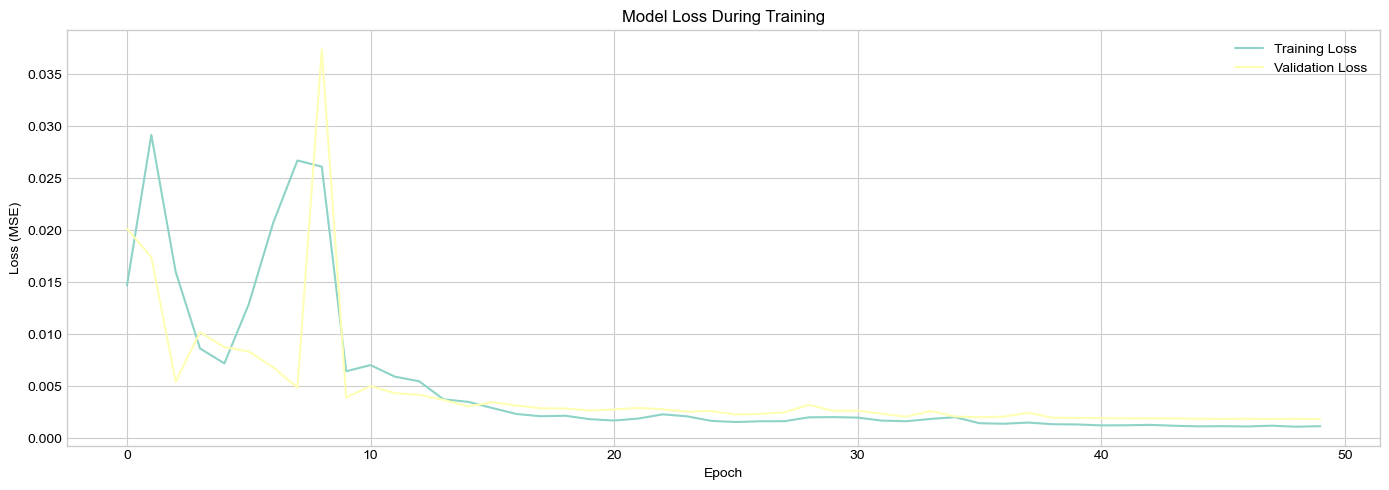

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(history.history['loss'], label='Training Loss')
ax.plot(history.history['val_loss'], label='Validation Loss')
ax.set_title('Model Loss During Training')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.legend()
plt.tight_layout()
plt.show()

## Evaluate model

In [8]:
results = evaluate_model(model, X_test, y_test, scaler)

print(f"RMSE: ${results['rmse']:.2f}")
print(f"MAE: ${results['mae']:.2f}")

RMSE: $6.89
MAE: $5.38


## Plot predictions vs actual

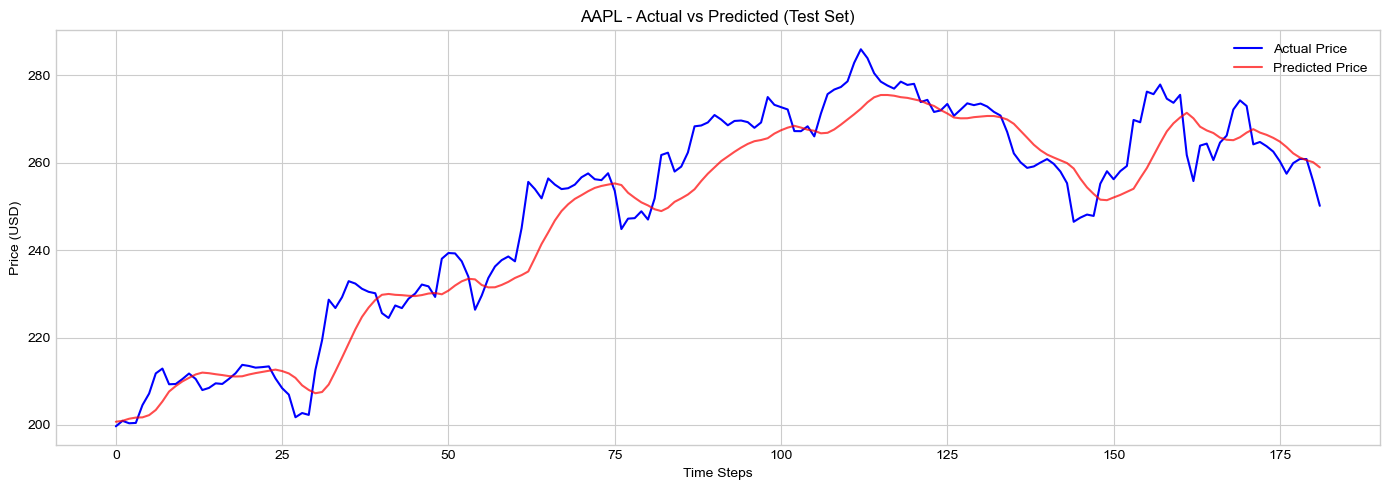

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(results['actual'], label='Actual Price', color='blue')
plt.plot(results['predictions'], label='Predicted Price', color='red', alpha=0.7)
plt.title(f'{ticker} - Actual vs Predicted (Test Set)')
plt.xlabel('Time Steps')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

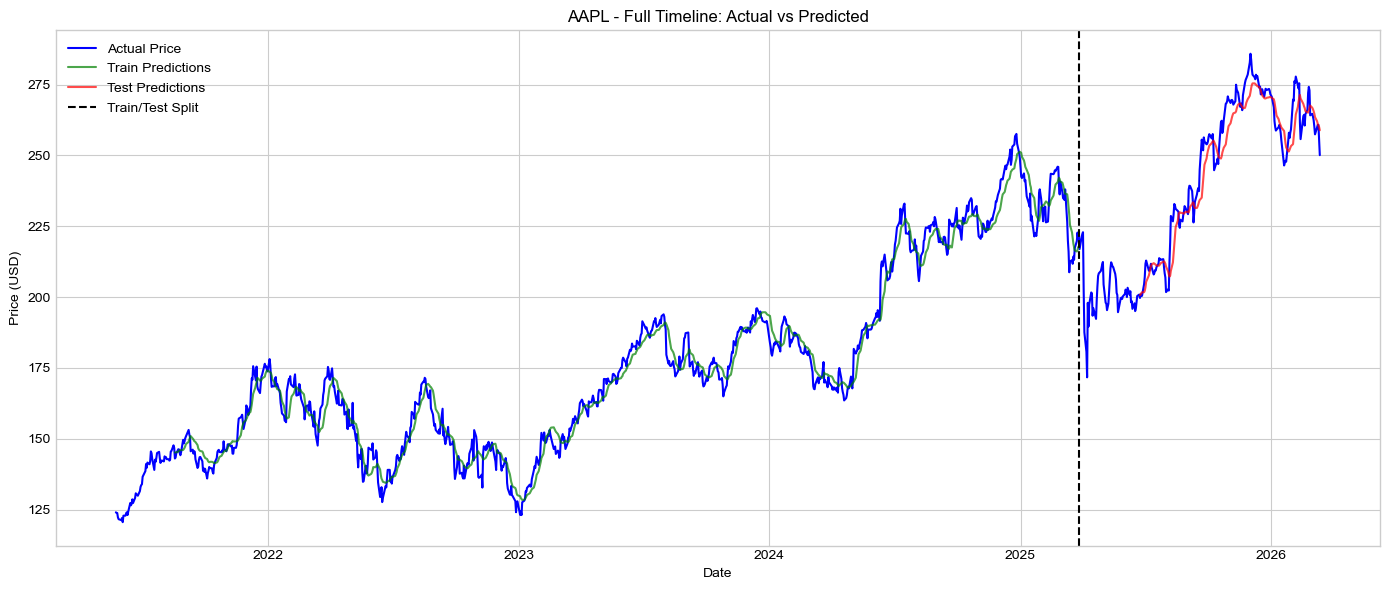

In [10]:

## Cell 10: Plot full timeline (train + test predictions)
train_predictions = model.predict(X_train)

n_features_scaler = scaler.n_features_in_
train_pred_padded = np.zeros((len(train_predictions), n_features_scaler))
train_pred_padded[:, 0] = train_predictions.flatten()
train_predictions_inv = scaler.inverse_transform(train_pred_padded)[:, 0]

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], label='Actual Price', color='blue')

train_plot_idx = df.index[seq_length:seq_length + len(train_predictions_inv)]
plt.plot(train_plot_idx, train_predictions_inv, label='Train Predictions', color='green', alpha=0.7)

test_start = len(train_data) + seq_length
test_plot_idx = df.index[test_start:test_start + len(results['predictions'])]
plt.plot(test_plot_idx, results['predictions'], label='Test Predictions', color='red', alpha=0.7)

plt.axvline(x=df.index[len(train_data)], color='black', linestyle='--', label='Train/Test Split')
plt.title(f'{ticker} - Full Timeline: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
## Cell 11: Prediction error analysis
errors = results['actual'] - results['predictions']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(errors, color='steelblue', alpha=0.7)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Prediction Error Over Time')
axes[0].set_xlabel('Time Steps')
axes[0].set_ylabel('Error (USD)')

axes[1].hist(errors, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title('Prediction Error Distribution')
axes[1].set_xlabel('Error (USD)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Mean Error: ${np.mean(errors):.2f}")
print(f"Std Error: ${np.std(errors):.2f}")

Mean Error: $2.56
Std Error: $6.40


In [12]:
## Cell 12: Save model and scaler
mape = np.mean(np.abs((results['actual'] - results['predictions']) / results['actual'])) * 100
accuracy_pct = 100 - mape

model.save('../models/lstm_model.keras')
joblib.dump(scaler, '../models/scaler.pkl')

with open('../models/training_config.json', 'w') as f:
    json.dump({
        "ticker": ticker,
        "seq_length": seq_length,
        "features": selected_features,
        "test_size": test_size,
        "epochs": len(history.history['loss']),
        "rmse": results['rmse'],
        "mae": results['mae'],
        "mape": mape,
        "accuracy_pct": accuracy_pct
    }, f, indent=2)

print("Model saved to: ../models/lstm_model.keras")
print("Scaler saved to: ../models/scaler.pkl")
print("Config saved to: ../models/training_config.json")

Model saved to: ../models/lstm_model.keras
Scaler saved to: ../models/scaler.pkl
Config saved to: ../models/training_config.json


In [13]:

## Cell 13: Summary
print("=" * 50)
print(f"TRAINING SUMMARY - {ticker}")
print("=" * 50)
print(f"Features used: {selected_features}")
print(f"Sequence length: {seq_length}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Epochs: {len(history.history['loss'])}")
print(f"Final training loss: {history.history['loss'][-1]:.6f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.6f}")
print(f"RMSE: ${results['rmse']:.2f}")
print(f"MAE: ${results['mae']:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"Prediction accuracy: {accuracy_pct:.2f}%")
print("=" * 50)
print("\nNext: 05_tuning.ipynb")

TRAINING SUMMARY - AAPL
Features used: ['Close', 'Volume_SMA_20', 'Volume', 'MACD_Signal']
Sequence length: 60
Training samples: 905
Test samples: 182
Epochs: 50
Final training loss: 0.001144
Final validation loss: 0.001832
RMSE: $6.89
MAE: $5.38
MAPE: 2.14%
Prediction accuracy: 97.86%

Next: 05_tuning.ipynb
